In [14]:
import os
import pandas as pd
import numpy as np
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
sns.set_theme(color_codes=True)
import plotly.express as px

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from utils.load_preprocess import separate_df_two_groups, load_preprocess, read_age_data

from sklearn.decomposition import PCA
import umap

import scipy.cluster.hierarchy as sch

# Initialize rng
rng = np.random.default_rng(2022)

# # Genes
# selecting top 100 genes gives 81 from feature selection using stability
# selecting top 500 genes gives 4111 from feature selection using stability
n_genes = 100

In [2]:
control_df, disease_df = separate_df_two_groups(n_genes)

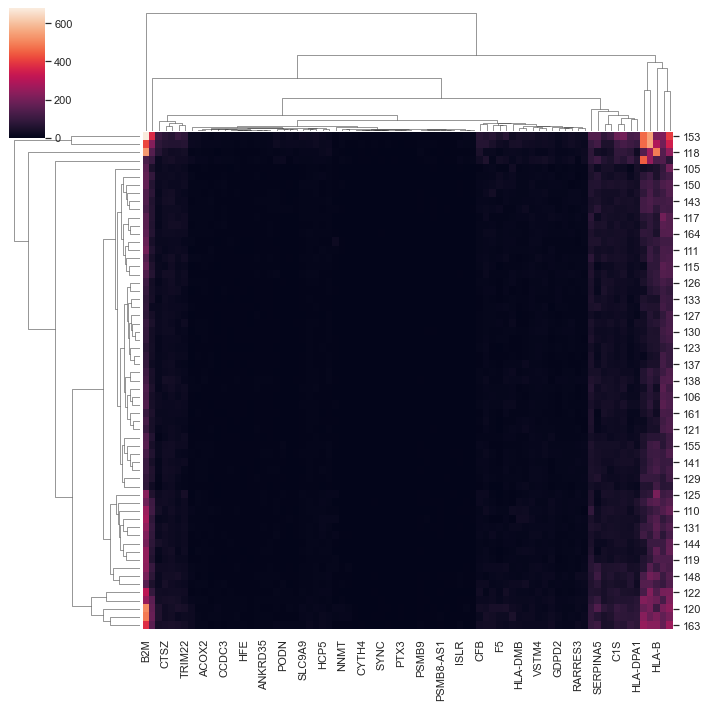

In [3]:
# Biclustering of diseased
g = sns.clustermap(disease_df, standard_scale=None, method='weighted')

/opt/anaconda3/envs/ML_tensorflow/lib/python3.7/site-packages/seaborn/matrix.py:659: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


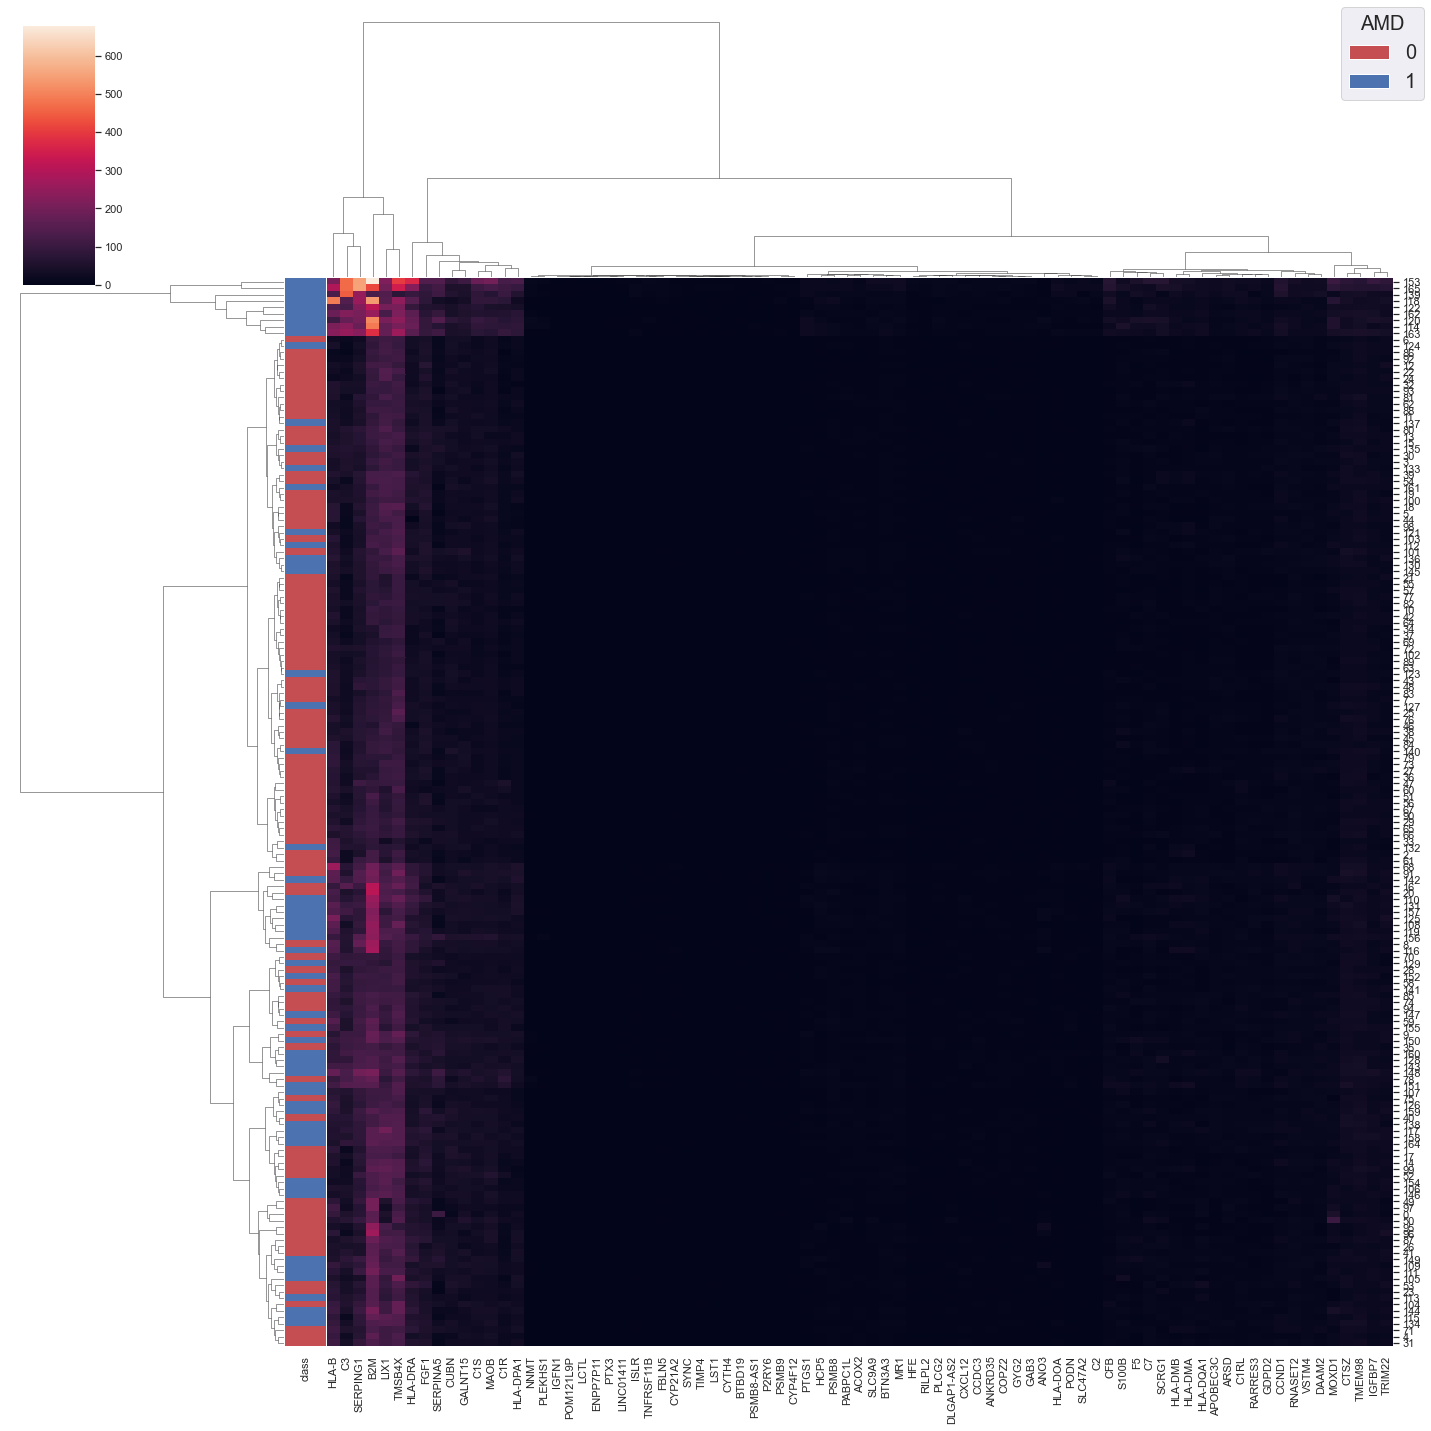

In [12]:
# Biclustering of entire data
data_fr = load_preprocess(n_genes, as_df=True)
lut = dict(zip(data_fr['class'].unique(), "rbg"))
row_colors = data_fr['class'].map(lut)
data_fr.drop('class', 1, inplace=True)
g = sns.clustermap(data_fr,
                   row_colors=row_colors,
                   standard_scale=None,
                   method='ward',
                   figsize=(20,20),
                   yticklabels=1,
                   xticklabels=1)

handles = [Patch(facecolor=lut[name]) for name in lut]
legend = plt.legend(handles, lut, title='AMD',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right', fontsize=20)
legend.get_title().set_fontsize('20')

plt.savefig(os.path.join('results', 'biclustering_raw.pdf'))

/opt/anaconda3/envs/ML_tensorflow/lib/python3.7/site-packages/seaborn/matrix.py:659: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


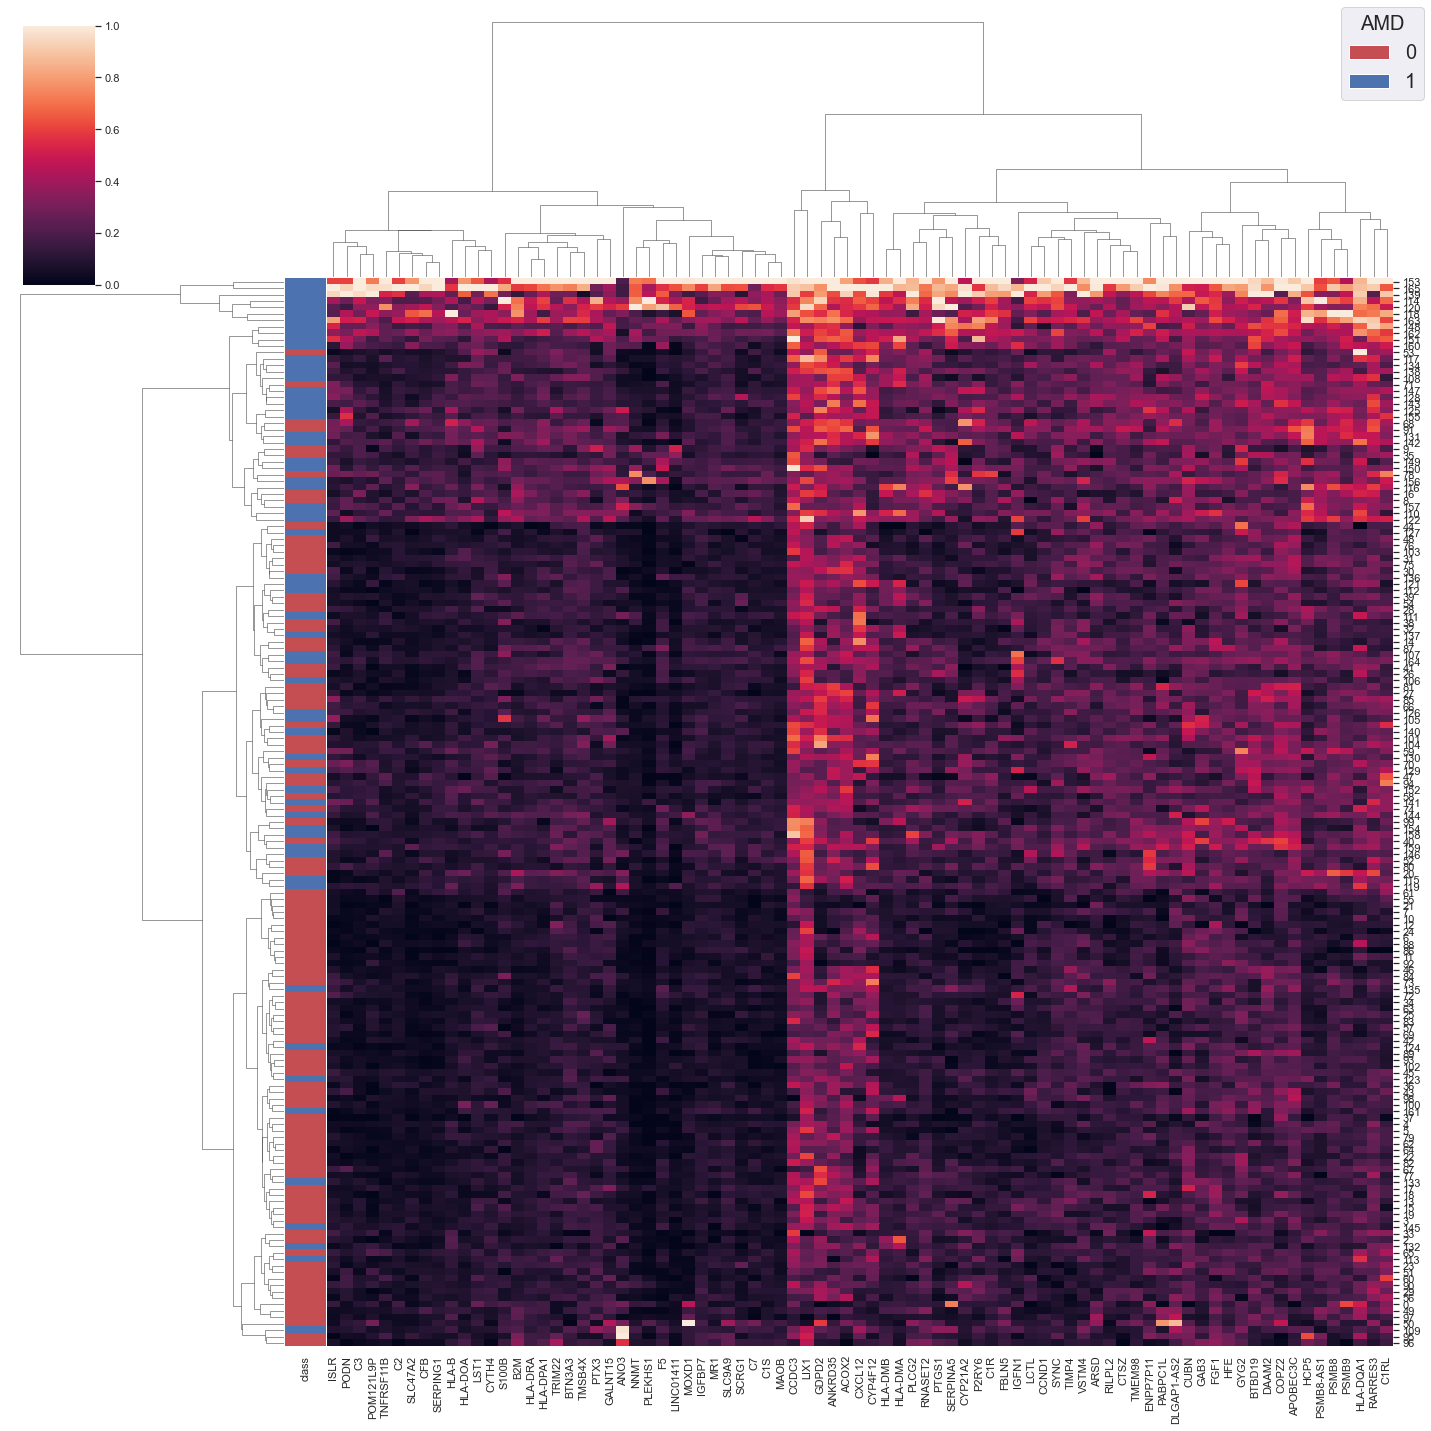

In [13]:
# Biclustering of entire data
data_fr = load_preprocess(n_genes, as_df=True)
lut = dict(zip(data_fr['class'].unique(), "rbg"))
row_colors = data_fr['class'].map(lut)
data_fr.drop('class', 1, inplace=True)
g = sns.clustermap(data_fr,
                   row_colors=row_colors,
                   standard_scale=1,
                   method='ward',
                   figsize=(20,20),
                   yticklabels=1,
                   xticklabels=1)

handles = [Patch(facecolor=lut[name]) for name in lut]
legend = plt.legend(handles, lut, title='AMD',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right', fontsize=20)
legend.get_title().set_fontsize('20')

plt.savefig(os.path.join('results', 'biclustering_normalized.pdf'))

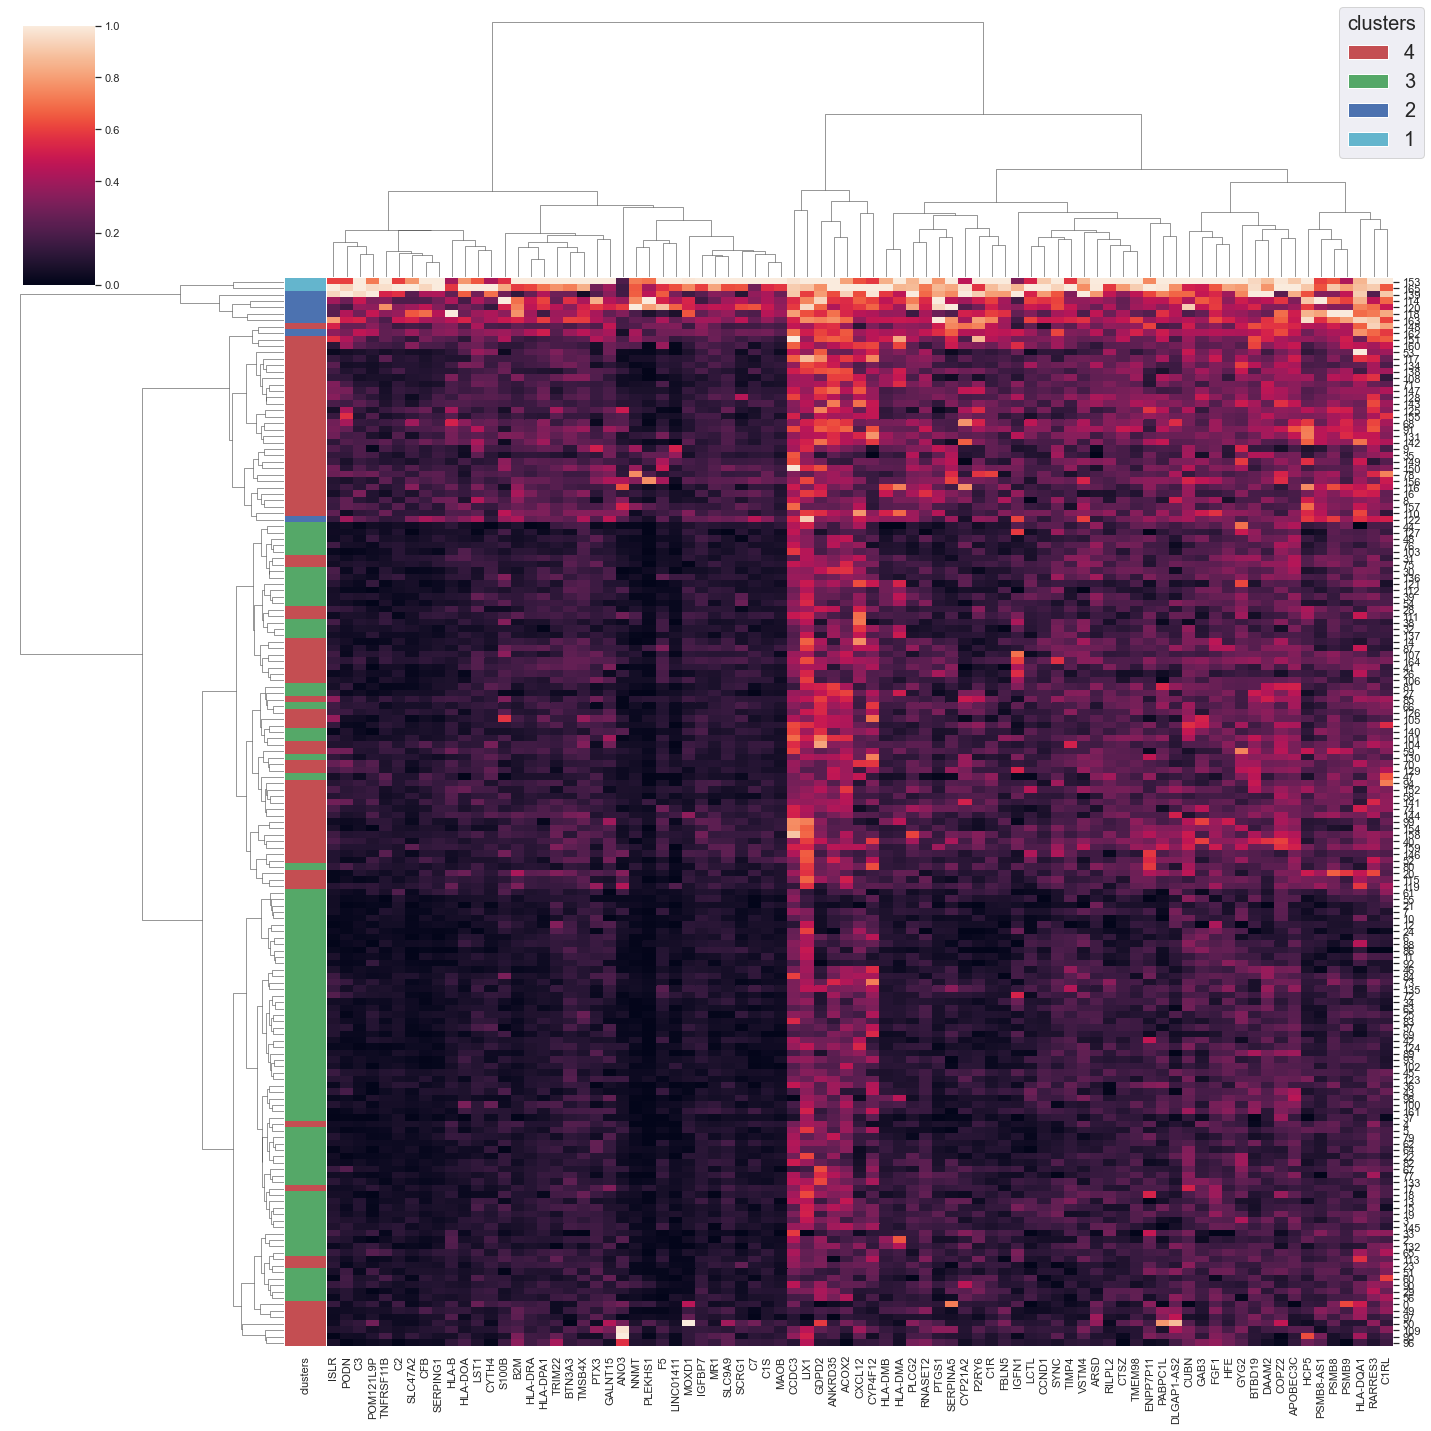

In [22]:
# Extract clusters
d = sch.distance.pdist(data_fr)
L = sch.linkage(d, method='ward')
# 0.2 can be modified to retrieve more stringent or relaxed clusters
clusters = sch.fcluster(L, 0.7*d.max(), 'distance')

# clusters indicices correspond to incides of original df
# for i,cluster in enumerate(clusters):
#     print(data_fr.index[i], cluster)
    
    # Biclustering of entire data
data_fr = load_preprocess(n_genes, as_df=True)
data_fr['clusters'] = clusters
lut = dict(zip(data_fr['clusters'].unique(), "rgbcmyk"))
row_colors = data_fr['clusters'].map(lut)
data_fr.drop(['class', 'clusters'], 1, inplace=True)
g = sns.clustermap(data_fr,
                   row_colors=row_colors,
                   standard_scale=1,
                   method='ward',
                   figsize=(20,20),
                   yticklabels=1,
                   xticklabels=1)

handles = [Patch(facecolor=lut[name]) for name in lut]
legend = plt.legend(handles, lut, title='clusters',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper right', fontsize=20)
legend.get_title().set_fontsize('20')

No handles with labels found to put in legend.


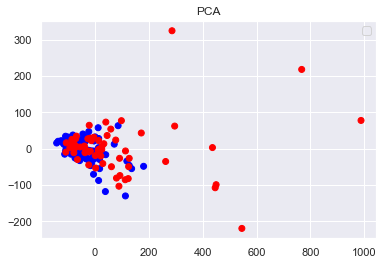

In [6]:
# PCA
X, y = load_preprocess(n_genes)
pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

plt.figure()
plt.scatter(X_r[:, 0], X_r[:, 1], c=y, cmap='bwr')
plt.legend()
plt.title('PCA');

Text(0.5, 1.0, 'UMAP projection')

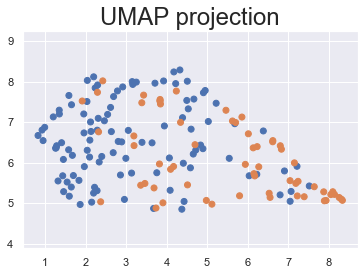

In [7]:
# UMAP
reducer = umap.UMAP(n_neighbors=5, min_dist=0.01, metric='mahalanobis')
X_sc = StandardScaler().fit_transform(X)
embedding = reducer.fit_transform(X_sc)
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[cl] for cl in y])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24)

In [11]:
reducer = umap.UMAP(n_neighbors=20, min_dist=0.5, n_components=3)
embedding = reducer.fit_transform(X_sc)

fig = px.scatter_3d(embedding,
                    x=embedding[:,0],
                    y=embedding[:,1],
                    z=embedding[:,2],
                    color=y,
                    opacity=0.6)
fig.show()

# Violin Plot

In [9]:
X = load_preprocess(n_genes, as_df=True)
ax = sns.violinplot(x="class", y="ENSG00000198483", data=X)

ValueError: Could not interpret input 'ENSG00000198483'

In [ ]:
data_fr.head